In [5]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [6]:
ARTIFACT_NAMES = ("pilot-summary.csv", "summary.csv", "episodes.csv", "requests.csv")


def resolve_experiment_root() -> Path:
    root_override = os.environ.get("OSNR_MARGIN_SWEEP_EXPERIMENT_ROOT")
    if root_override:
        return Path(root_override)

    candidates = (
        Path("optical_networking_gym_v2/examples/legacy_benchmark"),
        Path("examples/legacy_benchmark"),
        Path.cwd(),
    )
    for candidate in candidates:
        resolved = candidate.resolve()
        if (resolved / "osnr_margin_sweep.py").exists():
            return resolved

    return Path("optical_networking_gym_v2/examples/legacy_benchmark")


EXPERIMENT_ROOT = resolve_experiment_root()


def has_required_artifacts(path: Path) -> bool:
    return path.is_dir() and all((path / artifact_name).exists() for artifact_name in ARTIFACT_NAMES)


def find_latest_run_dir(root: Path) -> Path | None:
    if not root.exists():
        return None

    candidate_dirs = []
    for base_dir in sorted(root.iterdir()):
        if not base_dir.is_dir() or base_dir.name == "__pycache__":
            continue
        if has_required_artifacts(base_dir):
            candidate_dirs.append(base_dir)
            continue
        for child_dir in sorted(base_dir.iterdir()):
            if has_required_artifacts(child_dir):
                candidate_dirs.append(child_dir)
    if not candidate_dirs:
        return None
    return max(candidate_dirs, key=lambda path: path.stat().st_mtime)


RUN_DIR_OVERRIDE = os.environ.get("OSNR_MARGIN_SWEEP_RUN_DIR")
RUN_DIR = Path(RUN_DIR_OVERRIDE) if RUN_DIR_OVERRIDE else find_latest_run_dir(EXPERIMENT_ROOT)
if RUN_DIR is None:
    raise FileNotFoundError(
        f"No run directory with {', '.join(ARTIFACT_NAMES)} was found under {EXPERIMENT_ROOT}. "
        "Run osnr_margin_sweep.py first or set OSNR_MARGIN_SWEEP_RUN_DIR to a valid output directory."
    )
RUN_DIR = RUN_DIR.resolve()
print(f"Using RUN_DIR={RUN_DIR}")
PILOT_SUMMARY_CSV = RUN_DIR / "pilot-summary.csv"
SUMMARY_CSV = RUN_DIR / "summary.csv"
EPISODES_CSV = RUN_DIR / "episodes.csv"
REQUESTS_CSV = RUN_DIR / "requests.csv"

Using RUN_DIR=D:\mestrado\optical-networking-gym\optical_networking_gym_v2\examples\legacy_benchmark\results_fast_mp\20-04-23h11-osnr-margin-sweep


In [7]:
required_paths = {
    "pilot-summary.csv": PILOT_SUMMARY_CSV,
    "summary.csv": SUMMARY_CSV,
    "episodes.csv": EPISODES_CSV,
    "requests.csv": REQUESTS_CSV,
}
missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
    missing_text = ", ".join(missing)
    raise FileNotFoundError(
        f"Missing required artifacts in {RUN_DIR}: {missing_text}. "
        "Set OSNR_MARGIN_SWEEP_RUN_DIR to a valid output directory and rerun this notebook."
    )

pilot_df = pd.read_csv(PILOT_SUMMARY_CSV)
summary_df = pd.read_csv(SUMMARY_CSV)
episodes_df = pd.read_csv(EPISODES_CSV)
requests_df = pd.read_csv(REQUESTS_CSV)

selected_rows = pilot_df[pilot_df["is_selected_single_load"] == True]
if selected_rows.empty:
    raise ValueError("pilot-summary.csv does not identify a selected single load")
selected_single_load = float(selected_rows.iloc[0]["load"])

summary_df = summary_df.sort_values(["load", "margin"]).reset_index(drop=True)
episodes_df = episodes_df.sort_values(["load", "margin", "episode_index"]).reset_index(drop=True)
requests_df = requests_df.sort_values(["load", "margin", "episode_index", "request_index"]).reset_index(drop=True)

summary_df.head()


,date,topology_id,policy,analysis_group,is_single_load_focus,selected_single_load,target_effective_blocking_rate,load,margin,episodes,...,final_osnr_margin_p50,final_osnr_margin_p95,accepted_modulation_bpsk_ratio,accepted_modulation_qpsk_ratio,accepted_modulation_8qam_ratio,accepted_modulation_16qam_ratio,accepted_modulation_32qam_ratio,accepted_modulation_64qam_ratio,is_best_margin_for_load,best_margin_rank_within_load
0,20-04-23h02,nobel-eu,first_fit,multi_load,False,350.0,0.01,50.0,0.0,1,...,1.054449,3.624152,0.0,0.000,0.001,0.060,0.312,0.627,False,2
1,20-04-23h02,nobel-eu,first_fit,multi_load,False,350.0,0.01,50.0,0.5,1,...,1.506126,5.894373,0.0,0.000,0.009,0.085,0.325,0.581,True,1
2,20-04-23h02,nobel-eu,first_fit,multi_load,False,350.0,0.01,50.0,1.0,1,...,0.922307,2.440809,0.0,0.000,0.012,0.147,0.375,0.466,False,3
3,20-04-23h02,nobel-eu,first_fit,multi_load,False,350.0,0.01,50.0,1.5,1,...,1.100103,3.946817,0.0,0.009,0.027,0.194,0.404,0.366,False,4
4,20-04-23h02,nobel-eu,first_fit,multi_load,False,350.0,0.01,50.0,2.0,1,...,0.968857,2.550254,0.0,0.010,0.045,0.221,0.408,0.316,False,5


In [8]:
best_rows = summary_df[summary_df["is_best_margin_for_load"] == True].sort_values("load")
best_margin_table = best_rows[["load", "margin", "effective_blocking_rate_mean", "accepted_osnr_margin_mean"]]
min_row = summary_df.loc[summary_df["effective_blocking_rate_mean"].idxmin()]

print(f"Selected single-load focus: {selected_single_load:g}")
print("Best margin by load:")
display(best_margin_table)
print(
    "Lowest effective_blocking_rate observed:",
    f"load={float(min_row['load']):g}",
    f"margin={float(min_row['margin']):g}",
    f"effective_blocking_rate_mean={float(min_row['effective_blocking_rate_mean']):.4f}",
)


Selected single-load focus: 350
Best margin by load:


,load,margin,effective_blocking_rate_mean,accepted_osnr_margin_mean
1,50.0,0.5,0.321,1.283506
8,100.0,0.5,0.378,1.136891
20,150.0,3.0,0.360,0.913292
24,200.0,1.5,0.368,1.017367
32,250.0,2.0,0.372,0.991525
41,300.0,3.0,0.377,0.987347
47,350.0,2.5,0.396,0.951784


Lowest effective_blocking_rate observed: load=50 margin=0.5 effective_blocking_rate_mean=0.3210


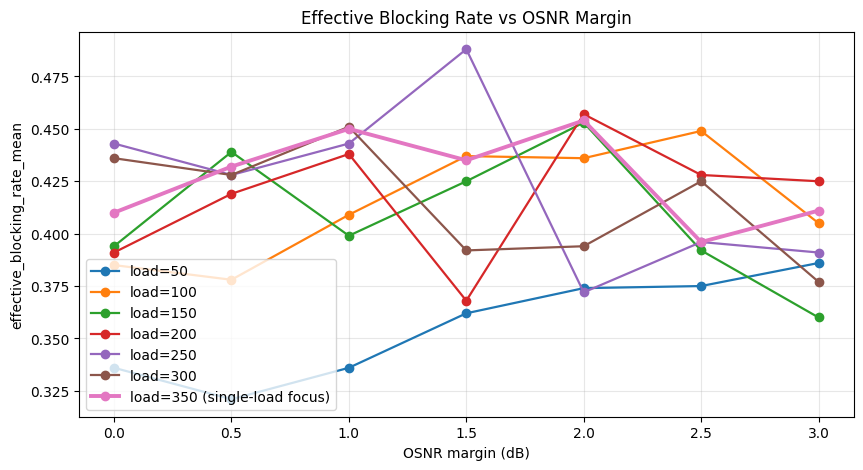

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for load, group in summary_df.groupby("load"):
    is_selected = abs(float(load) - selected_single_load) < 1e-9
    ax.plot(
        group["margin"],
        group["effective_blocking_rate_mean"],
        marker="o",
        linewidth=2.8 if is_selected else 1.6,
        label=f"load={float(load):g}" + (" (single-load focus)" if is_selected else ""),
    )
ax.set_title("Effective Blocking Rate vs OSNR Margin")
ax.set_xlabel("OSNR margin (dB)")
ax.set_ylabel("effective_blocking_rate_mean")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()


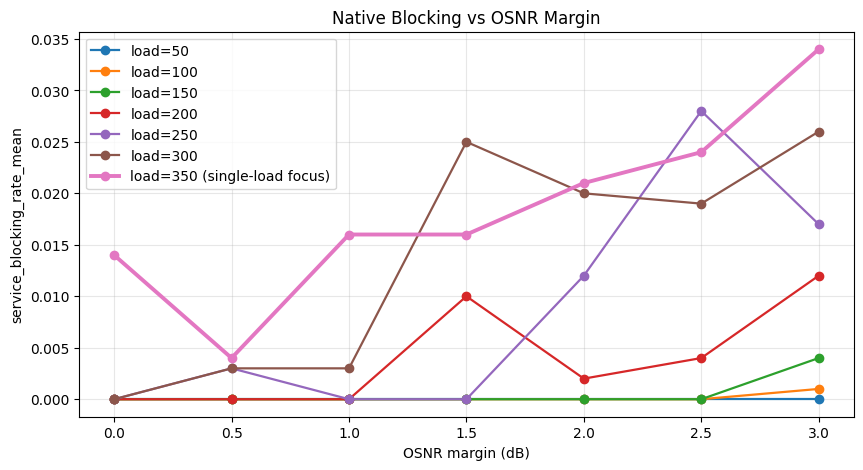

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for load, group in summary_df.groupby("load"):
    is_selected = abs(float(load) - selected_single_load) < 1e-9
    ax.plot(
        group["margin"],
        group["service_blocking_rate_mean"],
        marker="o",
        linewidth=2.8 if is_selected else 1.6,
        label=f"load={float(load):g}" + (" (single-load focus)" if is_selected else ""),
    )
ax.set_title("Native Blocking vs OSNR Margin")
ax.set_xlabel("OSNR margin (dB)")
ax.set_ylabel("service_blocking_rate_mean")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.show()


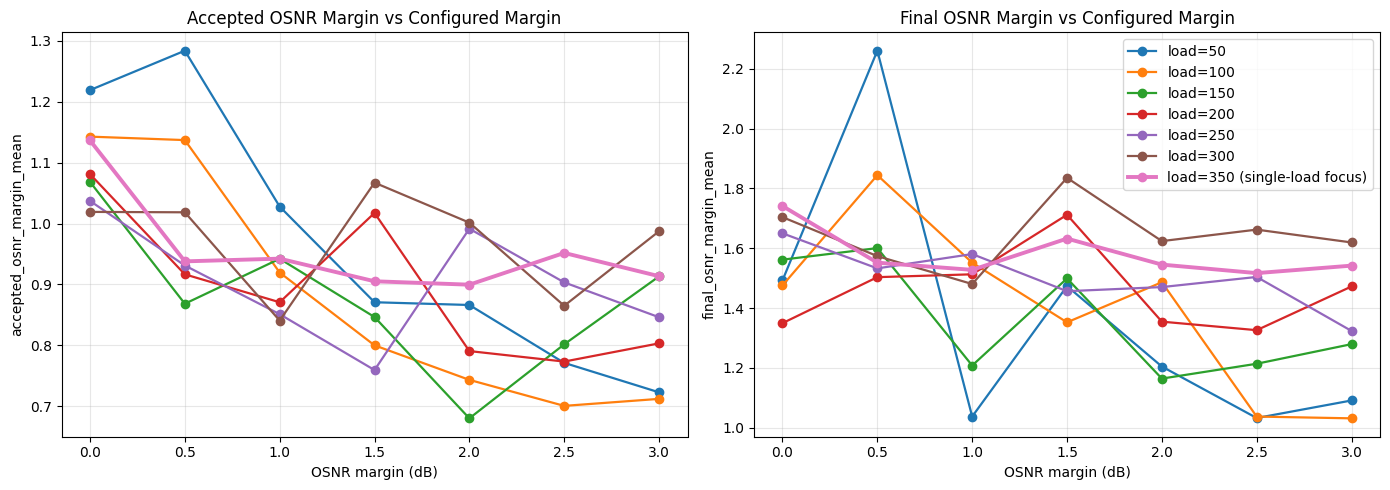

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for load, group in summary_df.groupby("load"):
    is_selected = abs(float(load) - selected_single_load) < 1e-9
    label = f"load={float(load):g}" + (" (single-load focus)" if is_selected else "")
    axes[0].plot(group["margin"], group["accepted_osnr_margin_mean"], marker="o", linewidth=2.8 if is_selected else 1.6, label=label)
    axes[1].plot(group["margin"], group["final_osnr_margin_mean"], marker="o", linewidth=2.8 if is_selected else 1.6, label=label)
axes[0].set_title("Accepted OSNR Margin vs Configured Margin")
axes[0].set_xlabel("OSNR margin (dB)")
axes[0].set_ylabel("accepted_osnr_margin_mean")
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Final OSNR Margin vs Configured Margin")
axes[1].set_xlabel("OSNR margin (dB)")
axes[1].set_ylabel("final_osnr_margin_mean")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()


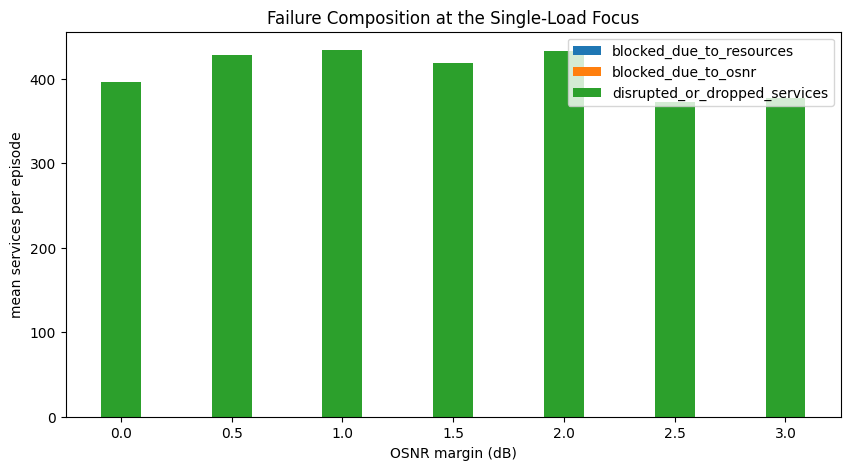

In [12]:
focus_summary = summary_df[summary_df["is_single_load_focus"] == True].sort_values("margin")
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(focus_summary["margin"], focus_summary["blocked_due_to_resources_mean"], width=0.18, label="blocked_due_to_resources")
ax.bar(
    focus_summary["margin"],
    focus_summary["blocked_due_to_osnr_mean"],
    width=0.18,
    bottom=focus_summary["blocked_due_to_resources_mean"],
    label="blocked_due_to_osnr",
)
ax.bar(
    focus_summary["margin"],
    focus_summary["disrupted_or_dropped_services_mean"],
    width=0.18,
    bottom=focus_summary["blocked_due_to_resources_mean"] + focus_summary["blocked_due_to_osnr_mean"],
    label="disrupted_or_dropped_services",
)
ax.set_title("Failure Composition at the Single-Load Focus")
ax.set_xlabel("OSNR margin (dB)")
ax.set_ylabel("mean services per episode")
ax.legend(loc="best")
plt.show()


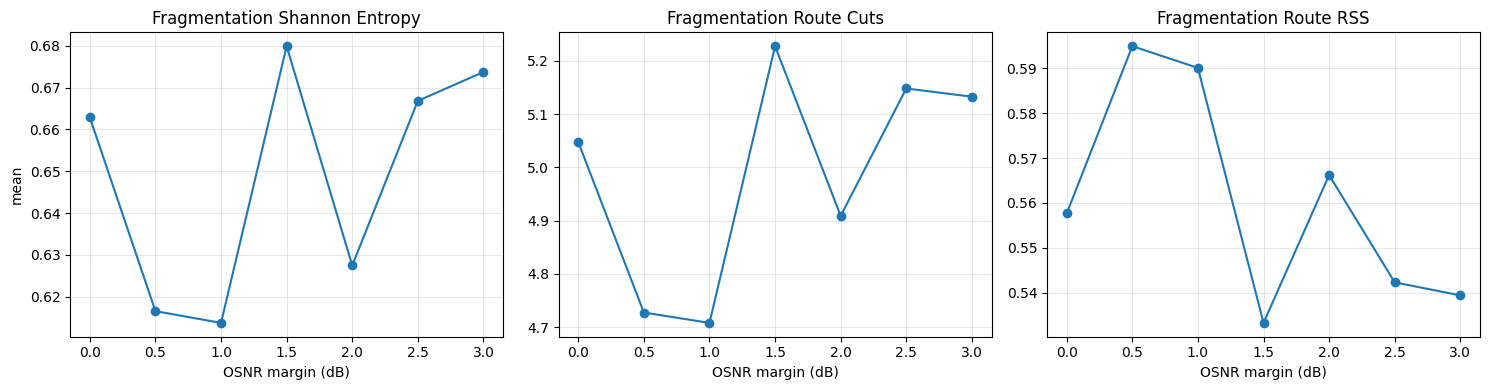

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].plot(focus_summary["margin"], focus_summary["fragmentation_shannon_entropy_mean"], marker="o")
axes[0].set_title("Fragmentation Shannon Entropy")
axes[0].set_ylabel("mean")
axes[1].plot(focus_summary["margin"], focus_summary["fragmentation_route_cuts_mean"], marker="o")
axes[1].set_title("Fragmentation Route Cuts")
axes[2].plot(focus_summary["margin"], focus_summary["fragmentation_route_rss_mean"], marker="o")
axes[2].set_title("Fragmentation Route RSS")
for ax in axes:
    ax.set_xlabel("OSNR margin (dB)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


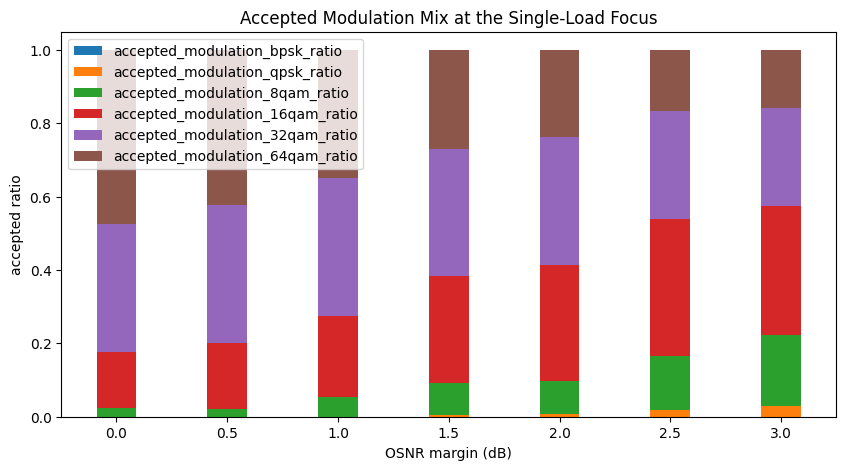

In [14]:
ratio_columns = [column for column in focus_summary.columns if column.startswith("accepted_modulation_") and column.endswith("_ratio")]
modulation_table = focus_summary[["margin", *ratio_columns]].set_index("margin")
fig, ax = plt.subplots(figsize=(10, 5))
bottom = pd.Series(0.0, index=modulation_table.index)
for column in ratio_columns:
    ax.bar(modulation_table.index, modulation_table[column], bottom=bottom, width=0.18, label=column)
    bottom = bottom + modulation_table[column]
ax.set_title("Accepted Modulation Mix at the Single-Load Focus")
ax.set_xlabel("OSNR margin (dB)")
ax.set_ylabel("accepted ratio")
ax.legend(loc="best")
plt.show()


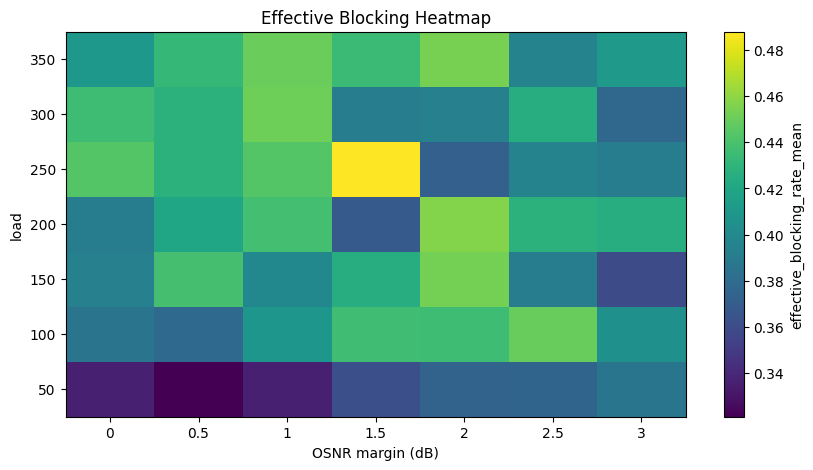

In [15]:
pivot = summary_df.pivot(index="load", columns="margin", values="effective_blocking_rate_mean").sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(pivot.values, aspect="auto", origin="lower")
ax.set_title("Effective Blocking Heatmap")
ax.set_xlabel("OSNR margin (dB)")
ax.set_ylabel("load")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{float(value):g}" for value in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{float(value):g}" for value in pivot.index])
fig.colorbar(image, ax=ax, label="effective_blocking_rate_mean")
plt.show()


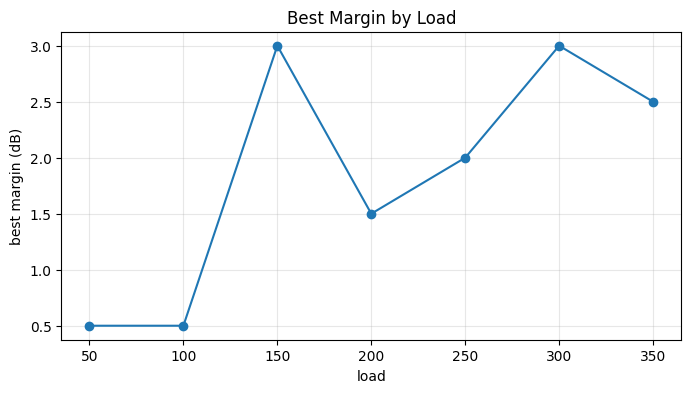

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_rows["load"], best_rows["margin"], marker="o")
ax.set_title("Best Margin by Load")
ax.set_xlabel("load")
ax.set_ylabel("best margin (dB)")
ax.grid(True, alpha=0.3)
plt.show()


C:\Users\TALLES MAGALHAES\AppData\Local\Temp\ipykernel_83588\2493724191.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=box_labels)


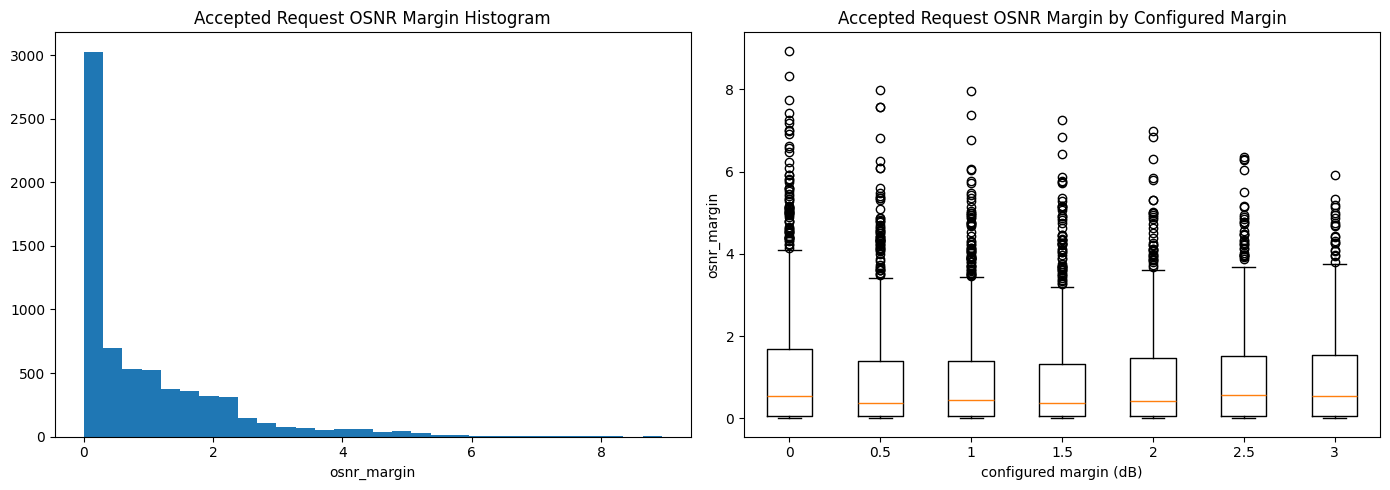

In [17]:
focus_requests = requests_df[(requests_df["is_single_load_focus"] == True) & (requests_df["accepted"] == True)].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(focus_requests["osnr_margin"], bins=30)
axes[0].set_title("Accepted Request OSNR Margin Histogram")
axes[0].set_xlabel("osnr_margin")
box_data = [group["osnr_margin"].tolist() for _margin, group in focus_requests.groupby("margin")]
box_labels = [f"{float(margin):g}" for margin, _group in focus_requests.groupby("margin")]
axes[1].boxplot(box_data, labels=box_labels)
axes[1].set_title("Accepted Request OSNR Margin by Configured Margin")
axes[1].set_xlabel("configured margin (dB)")
axes[1].set_ylabel("osnr_margin")
plt.tight_layout()
plt.show()


C:\Users\TALLES MAGALHAES\AppData\Local\Temp\ipykernel_83588\2756083442.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(cuts_data, labels=labels)
C:\Users\TALLES MAGALHAES\AppData\Local\Temp\ipykernel_83588\2756083442.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(rss_data, labels=labels)


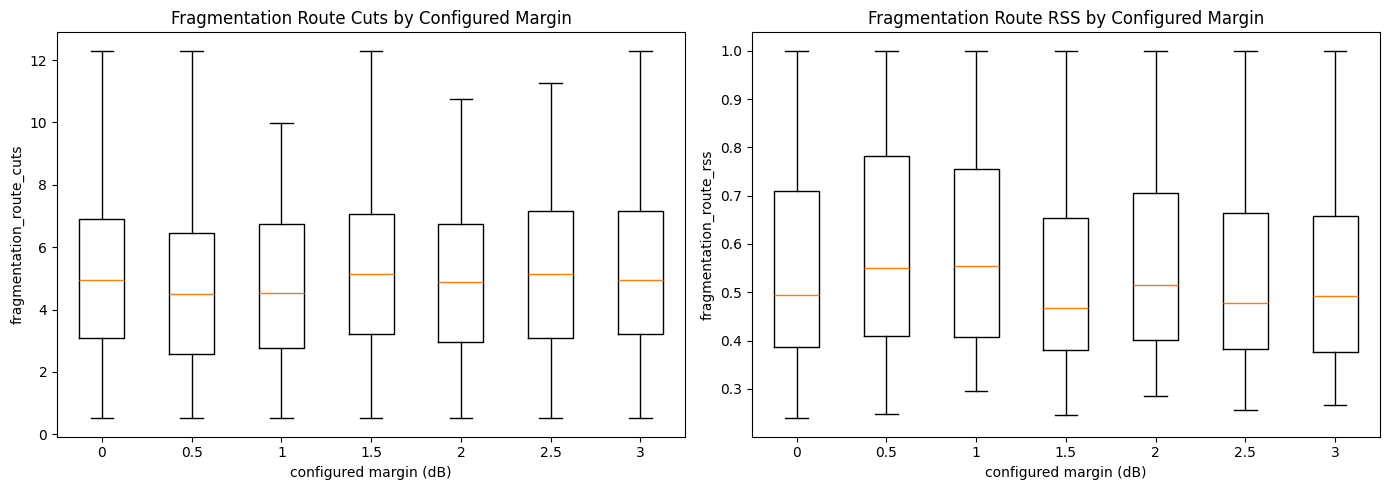

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cuts_data = [group["fragmentation_route_cuts"].tolist() for _margin, group in focus_requests.groupby("margin")]
rss_data = [group["fragmentation_route_rss"].tolist() for _margin, group in focus_requests.groupby("margin")]
labels = [f"{float(margin):g}" for margin, _group in focus_requests.groupby("margin")]
axes[0].boxplot(cuts_data, labels=labels)
axes[0].set_title("Fragmentation Route Cuts by Configured Margin")
axes[0].set_xlabel("configured margin (dB)")
axes[0].set_ylabel("fragmentation_route_cuts")
axes[1].boxplot(rss_data, labels=labels)
axes[1].set_title("Fragmentation Route RSS by Configured Margin")
axes[1].set_xlabel("configured margin (dB)")
axes[1].set_ylabel("fragmentation_route_rss")
plt.tight_layout()
plt.show()


In [ ]:
figures_dir = RUN_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
for figure_number in plt.get_fignums():
    figure = plt.figure(figure_number)
    figure.savefig(figures_dir / f"figure_{figure_number}.png", dpi=200, bbox_inches="tight")
print(f"Saved {len(plt.get_fignums())} figure(s) to {figures_dir}")


Saved 0 figure(s) to D:\mestrado\optical-networking-gym\optical_networking_gym_v2\examples\legacy_benchmark\results_fast_mp\20-04-23h11-osnr-margin-sweep\figures


: 